In [ ]:
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import START, END, MessagesState
from langgraph.graph.state import StateGraph
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
class AgentState(MessagesState):
    next_agent: str

In [3]:
@tool
def search_web(query: str) -> TavilySearchResults:
    """Search the web for recent information."""
    # Implement your web search logic here, e.g., using an API
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

In [4]:
@tool
def write_summary(content: str) -> str:
    """Write a summary of the given content."""
    # Implement your summarization logic here, e.g., using an LLM
    summary = f"Summary of the content: {content[:500]}..."  # Placeholder summary
    return summary

In [5]:
from langchain.chat_models import init_chat_model

llm = init_chat_model("gpt-4o")
llm

ChatOpenAI(output_version=None, profile={'name': 'GPT-4o', 'release_date': '2024-05-13', 'last_updated': '2024-08-06', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x10f9a2420>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x11053a570>, root_client=<openai.OpenAI object at 0x10fa62de0>, root_async_client=<openai.AsyncOpenAI object at 0x1106861e0>, model_name='gpt-4o', model_kwargs={}, openai_api_key=SecretStr('**********')

In [6]:
def researcher_agent(state: AgentState) -> str:
    """Researcher agent that searches the web for information."""

    messages = state["messages"]

    system_msg = SystemMessage(content="You are a researcher agent. Your job is to gather information on a given topic.")

    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "writer"
    }

In [13]:
def writer_agent(state: AgentState) -> str:
    """Writer agent that summarizes information."""

    messages = state["messages"]

    system_msg = SystemMessage(content="You are a writer agent. Your job is to summarize the information provided by the researcher agent.")

    # writer_llm = llm.bind_tools([write_summary])
    response = llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "end"
    }

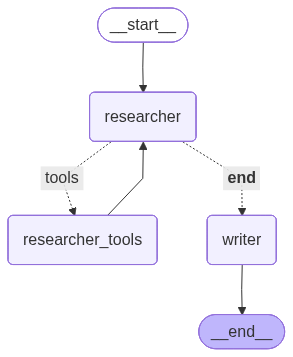

In [ ]:
from langgraph.prebuilt import tools_condition

tool_node = ToolNode([search_web])

workflow = StateGraph(MessagesState)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("researcher_tools", tool_node)
workflow.add_node("writer", writer_agent)

workflow.set_entry_point("researcher")
workflow.add_conditional_edges("researcher", tools_condition, {"tools": "researcher_tools", "next": "writer"})
workflow.add_edge("researcher_tools", "researcher")
workflow.add_edge("writer", END)

final_workflow = workflow.compile()
final_workflow

In [21]:
response=final_workflow.invoke({"messages":"Reasearch about the usecase of agentic ai in business"})

response["messages"][-1].content

'What specific impact does agentic AI have on the productivity and performance of businesses?'